## 1. Data Ingestion

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=50,resize=0.4)
X = lfw_people.data
y = lfw_people.target 
target_names = lfw_people.target_names

print(X.shape)
print(y.shape)
print(target_names.shape)
for name in target_names:
    print(name)

(1560, 1850)
(1560,)
(12,)
Ariel Sharon
Colin Powell
Donald Rumsfeld
George W Bush
Gerhard Schroeder
Hugo Chavez
Jacques Chirac
Jean Chretien
John Ashcroft
Junichiro Koizumi
Serena Williams
Tony Blair


In [2]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)
print(X_train.shape)
print(y_train.shape)

print(X_train.dtype)
print(y_train.dtype)

(1092, 1850)
(1092,)
float32
int64


## 2. Clean Data & Feature Engineering

(1850,)


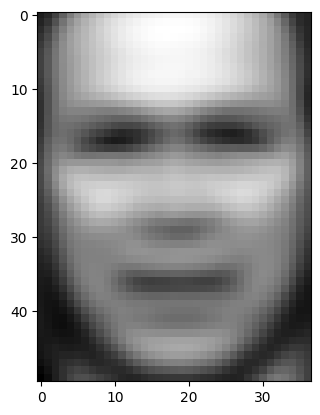

In [3]:
from matplotlib.pyplot import gray
mean_face = X_train.mean(axis=0)
print(mean_face.shape)
X_train_centered = X_train-mean_face
X_test_centered = X_test - mean_face

plt.imshow(mean_face.reshape(50,37),cmap="gray");

## 3.Training Model

(1092, 1850)
(1850, 1092)
(1092,)


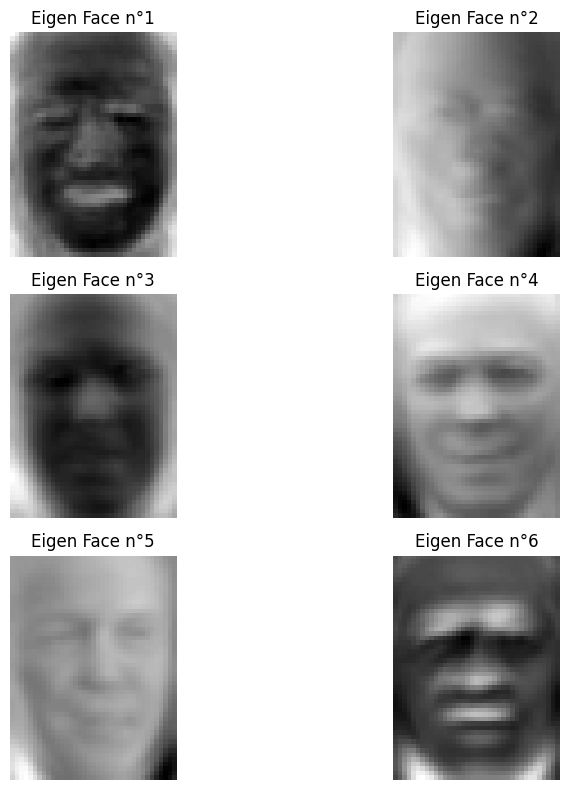

In [4]:
N = 1092 # training samples
U,S,V_transposed = np.linalg.svd(X_train_centered,full_matrices=False)
print(V_transposed.shape)
eigenvectors = V_transposed.T 
eigenvalues = S**2/(N-1)

print(eigenvectors.shape)
print(eigenvalues.shape)

#visualize the eigenfaces
n_faces = 6
fig,ax = plt.subplots(3,2,figsize=(10,8))
for i in range(n_faces):
    row = i//2
    col = i%2
    ax[row,col].imshow(eigenvectors[:,i].reshape(50,37),cmap="gray")
    ax[row,col].set_title(f"Eigen Face n°{i+1}")
    ax[row,col].axis("off")

plt.tight_layout()
plt.show()

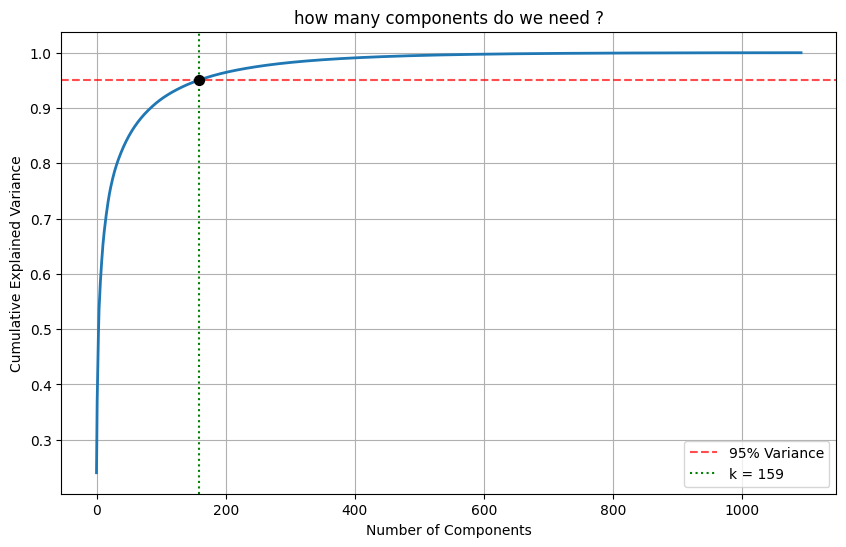

In [5]:
explained_variance = eigenvalues/np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

k_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.figure(figsize=(10,6))
plt.plot(cumulative_variance,linewidth=2,)
plt.title("how many components do we need ?")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.axhline(y=0.95,color="r",linestyle="--",label="95% Variance",alpha=0.7)
plt.axvline(x=k_95,color="g",linestyle=":",label=f"k = {k_95}")
plt.scatter(k_95,0.95,color="black",zorder=5,s=50)
plt.legend(loc=4)
plt.show()

In [6]:
k=159
compressed_X_train = X_train_centered@eigenvectors[:,:k]
compressed_X_test = X_test_centered@eigenvectors[:,:k]

print(compressed_X_train.shape) # (1092,159)
print(compressed_X_test.shape) # (468,159)

(1092, 159)
(468, 159)


## 4. Inference & Evaluation

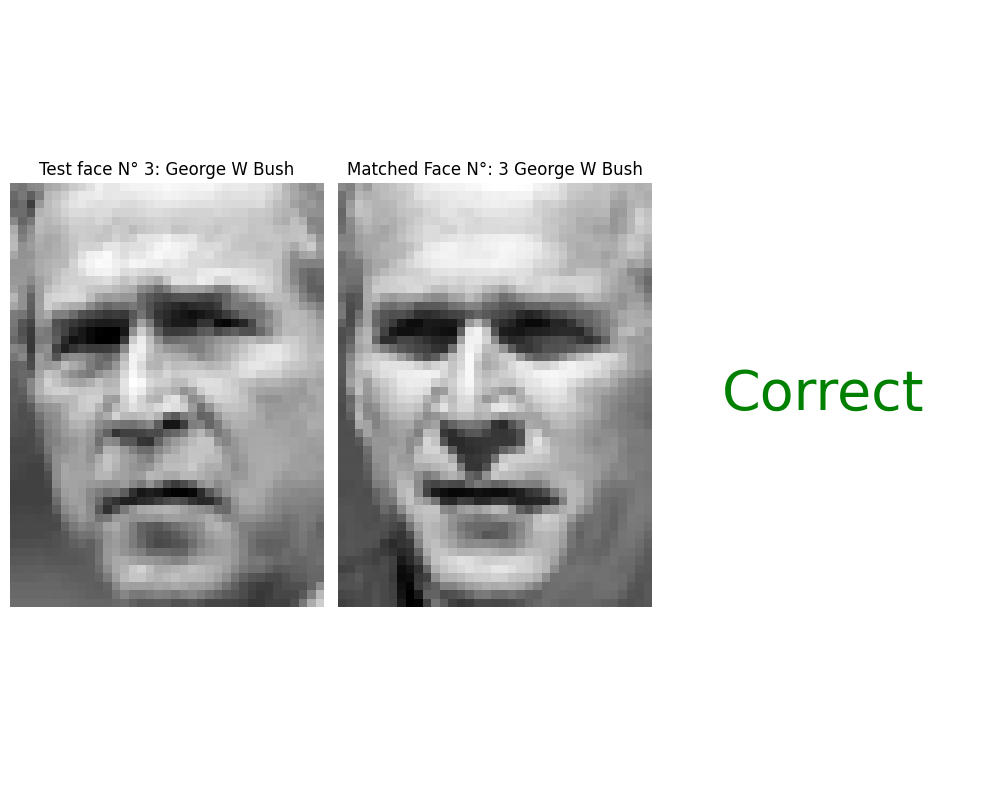

In [12]:
def cosine_similarity(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

def recognize_face(compressed_test_face,compressed_X_train,target_label,target_names):
    """
    compressed_test_face : it represents the face that we will use to match it (Test Face (159) )
    compressed_X_train: it holds every training face on the eigenface basis (1092,159)
    target: it holds the labels of every training image # (1092,)
    """
    similarities = np.array([cosine_similarity(compressed_test_face,training_face) for training_face in compressed_X_train])
    best_idx = np.argmax(similarities)
    return target_names[target_label[best_idx]],target_label[best_idx],similarities[best_idx],best_idx

predicted_name,predicted_label,confidence,best_idx = recognize_face(compressed_X_test[1],compressed_X_train,y_train,target_names)

fig,ax = plt.subplots(1,3,figsize=(10,8))
ax[0].imshow(X_test[1].reshape(50,37),cmap="gray")
ax[0].set_title(f"Test face N° {y_test[1]}: {target_names[y_test[1]]}")
ax[0].axis("off")

ax[1].imshow(X_train[best_idx].reshape(50,37),cmap="gray")
ax[1].set_title(f"Matched Face N°: {predicted_label} {predicted_name}")
ax[1].axis("off")

is_correct = "Correct" if y_test[1] == predicted_label else "Wrong"
ax[2].text(0.5,0.5,is_correct,fontsize=40,ha="center",va="center",color="green" if y_test[1] == predicted_label else "red")
ax[2].axis("off")

plt.tight_layout()
plt.show()


In [10]:
correct = 0
failures = []
for i in range(len(X_test)):
    predicted_name,predicted_label,confidence,best_idx = recognize_face(compressed_X_test[i],compressed_X_train,y_train,target_names)
    if predicted_label == y_test[i]:
        correct += 1
    else:
        failures.append((i,best_idx))
print(correct/len(X_test))

0.48717948717948717


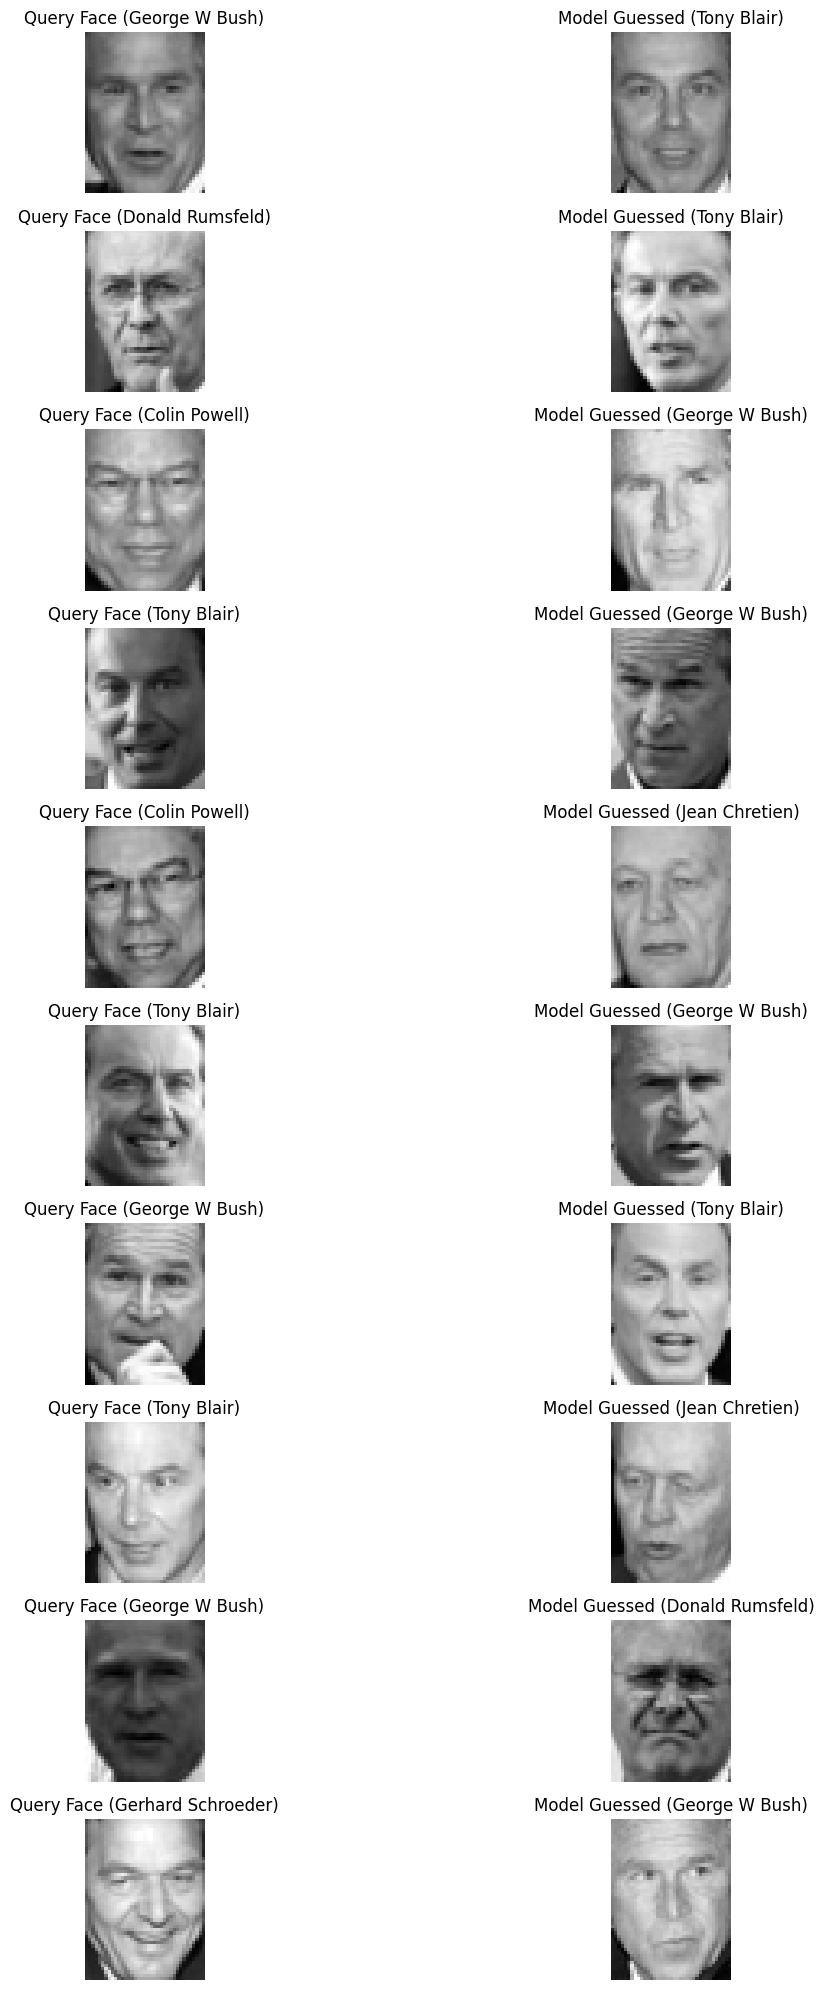

In [20]:
fig, ax = plt.subplots(10, 2, figsize=(15, 20))

for i in range(min(10, len(failures))):
    
    query_idx = failures[i][0]
    match_idx = failures[i][1]
    
    ax[i,0].imshow(X_test[query_idx].reshape(50, 37), cmap="gray")
    ax[i,0].set_title(f"Query Face ({target_names[y_test[query_idx]]})")
    ax[i,0].axis("off")

    ax[i,1].imshow(X_train[match_idx].reshape(50, 37), cmap="gray")
    ax[i,1].set_title(f"Model Guessed ({target_names[y_train[match_idx]]})")
    ax[i,1].axis("off")

plt.tight_layout()
plt.show()